# Logistic Regression Baseline Model

This notebook builds our baseline logistic regression model for classifying which social media platform a post belongs to.

## Goals
- load the final train, validation, test splits processed and saved from the create_datasets notebook
- create a baseline logistic regression model using TF-IDF vectors to encode the post's text and additional text statistics such as number of questions, hashtags, URLs, etc
- explicitly exclude non-text fields such as date/time metadata that could be learned in unuseful ways by the model
- evaluate performance


In [2]:
%pip install polars pyarrow pandas matplotlib scikit-learn scipy


[notice] A new release of pip is available: 24.2 -> 26.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [3]:
from pathlib import Path
import re
import html
from time import perf_counter

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix, hstack
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

pl.Config.set_tbl_rows(12)
pl.Config.set_tbl_cols(14)

polars.config.Config

## Paths

In [4]:
PROJECT_ROOT = Path.cwd().parent

TRAIN_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "train_210k.parquet"
VAL_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "val_45k.parquet"
TEST_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset_local_duckdb" / "test_45k.parquet"

MODEL_OUTPUT_DIR = PROJECT_ROOT / "outputs" / "modeling"
MODEL_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print(TRAIN_PATH, TRAIN_PATH.exists())
print(VAL_PATH, VAL_PATH.exists())
print(TEST_PATH, TEST_PATH.exists())

/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/train_210k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/val_45k.parquet True
/Users/mhedlund/CIS2450/cis2450-final-project/data/processed/final_dataset_local_duckdb/test_45k.parquet True


## Load train, validation, test data

In [5]:
train_df = pl.read_parquet(TRAIN_PATH)
val_df = pl.read_parquet(VAL_PATH)
test_df = pl.read_parquet(TEST_PATH)

print(train_df.shape, val_df.shape, test_df.shape)
train_df.head()

(209999, 18) (45000, 18) (45001, 18)


platform,post_id,author,text,created_at,likes,retweets,…,month,year_month,score,community,num_comments,upvote_ratio,parent_id
str,str,str,str,datetime[μs],f64,f64,…,i8,str,f64,str,f64,f64,str
"""hackernews""","""4380112""","""beagle3""","""> the license terms are more r…",2012-08-14 05:56:40,null,null,…,8,"""2012-08""",0.0,null,null,null,"""4380100"""
"""hackernews""","""13775458""","""simplehuman""","""You read these articles too cl…",2017-03-02 11:39:10,null,null,…,3,"""2017-03""",0.0,null,null,null,"""13775414"""
"""hackernews""","""39727388""","""toomuchtodo""","""Like <a href=""https://www.he36…",2024-03-16 12:44:56,null,null,…,3,"""2024-03""",0.0,null,null,null,"""39726890"""
"""hackernews""","""41179214""","""I_am_uncreative""","""In the English Language, ""Amer…",2024-08-07 04:02:06,null,null,…,8,"""2024-08""",0.0,null,null,null,"""41177797"""
"""hackernews""","""12680008""","""acaciapalm""","""I used the word ""show"" not ""pr…",2016-10-10 17:46:45,null,null,…,10,"""2016-10""",0.0,null,null,null,"""12679942"""


## Quick class balance checks 

In [6]:
print(train_df.group_by("platform").len().sort("platform"))
print(val_df.group_by("platform").len().sort("platform"))
print(test_df.group_by("platform").len().sort("platform"))

shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 70000 │
│ reddit     ┆ 70000 │
│ twitter    ┆ 69999 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15000 │
└────────────┴───────┘
shape: (3, 2)
┌────────────┬───────┐
│ platform   ┆ len   │
│ ---        ┆ ---   │
│ str        ┆ u32   │
╞════════════╪═══════╡
│ hackernews ┆ 15000 │
│ reddit     ┆ 15000 │
│ twitter    ┆ 15001 │
└────────────┴───────┘


## Feature policy

We keep only the text-derived features for the baseline model.

We explicitly do not use features like 
- created_at, year, month, year_month, post_id, author
- platform-specific metadata such as community, likes, retweets, replies, quotes, score, parent_id
because they might encode details about the platform instead of determining it from the language of the post itself

## Add text statistics

In [7]:
def add_text_stats(df: pl.DataFrame) -> pl.DataFrame:
    return df.with_columns([
        pl.col("text").str.count_matches(r"\?").alias("num_questions"),
        pl.col("text").str.count_matches(r"!").alias("num_exclamations"),
        pl.col("text").str.count_matches(r"#\w+").alias("num_hashtags"),
        pl.col("text").str.count_matches(r"@\w+").alias("num_mentions"),
        pl.col("text").str.count_matches(r"http[s]?://").alias("num_urls"),
        pl.col("text").str.count_matches(r"\d").alias("num_digits"),
        pl.col("text").str.count_matches(r"\b[A-Z]{2,}\b").alias("num_allcaps_words"),
        pl.col("text").str.count_matches(r"\b\w+\b").alias("num_words"),
    ]).with_columns([
        (
            pl.col("text_len") /
            pl.when(pl.col("num_words") > 0).then(pl.col("num_words")).otherwise(1)
        ).alias("avg_word_len"),
    ])

train_df = add_text_stats(train_df)
val_df = add_text_stats(val_df)
test_df = add_text_stats(test_df)

train_df.head()

platform,post_id,author,text,created_at,likes,retweets,…,num_hashtags,num_mentions,num_urls,num_digits,num_allcaps_words,num_words,avg_word_len
str,str,str,str,datetime[μs],f64,f64,…,u32,u32,u32,u32,u32,u32,f64
"""hackernews""","""4380112""","""beagle3""","""> the license terms are more r…",2012-08-14 05:56:40,null,null,…,0,0,0,0,3,51,6.0
"""hackernews""","""13775458""","""simplehuman""","""You read these articles too cl…",2017-03-02 11:39:10,null,null,…,0,0,0,0,0,14,5.5
"""hackernews""","""39727388""","""toomuchtodo""","""Like <a href=""https://www.he36…",2024-03-16 12:44:56,null,null,…,0,0,2,6,0,25,6.72
"""hackernews""","""41179214""","""I_am_uncreative""","""In the English Language, ""Amer…",2024-08-07 04:02:06,null,null,…,0,0,0,0,1,23,5.565217
"""hackernews""","""12680008""","""acaciapalm""","""I used the word ""show"" not ""pr…",2016-10-10 17:46:45,null,null,…,0,0,0,0,0,43,5.232558


## Change to pandas for scikit-learn

In [8]:
train_pdf = train_df.to_pandas()
val_pdf = val_df.to_pandas()
test_pdf = test_df.to_pandas()

print(train_pdf.columns.tolist())

['platform', 'post_id', 'author', 'text', 'created_at', 'likes', 'retweets', 'replies', 'quotes', 'text_len', 'year', 'month', 'year_month', 'score', 'community', 'num_comments', 'upvote_ratio', 'parent_id', 'num_questions', 'num_exclamations', 'num_hashtags', 'num_mentions', 'num_urls', 'num_digits', 'num_allcaps_words', 'num_words', 'avg_word_len']


## Text statistics feature list

In [9]:
TEXT_STAT_COLS = [
    "text_len",
    "num_questions",
    "num_exclamations",
    "num_hashtags",
    "num_mentions",
    "num_urls",
    "num_digits",
    "num_allcaps_words",
    "num_words",
    "avg_word_len",
]

## Build TF-IDF and numeric feature matrices

Here we build use TF-IDF to encode the text of the posts using 1-grams and 2-grams


In [10]:
X_train_text = train_pdf["text"].astype(str)
X_val_text = val_pdf["text"].astype(str)
X_test_text = test_pdf["text"].astype(str)

X_train_num = train_pdf[TEXT_STAT_COLS].astype(float)
X_val_num = val_pdf[TEXT_STAT_COLS].astype(float)
X_test_num = test_pdf[TEXT_STAT_COLS].astype(float)

y_train = train_pdf["platform"]
y_val = val_pdf["platform"]
y_test = test_pdf["platform"]

print("Fitting TF-IDF...")
tfidf = TfidfVectorizer(
    max_features=20000,
    min_df=5,
    max_df=0.9,
    ngram_range=(1, 2),
    stop_words="english",
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_val_tfidf = tfidf.transform(X_val_text)
X_test_tfidf = tfidf.transform(X_test_text)

print("TF-IDF shapes:", X_train_tfidf.shape, X_val_tfidf.shape, X_test_tfidf.shape)

scaler = StandardScaler(with_mean=False)

X_train_num_scaled = scaler.fit_transform(X_train_num)
X_val_num_scaled = scaler.transform(X_val_num)
X_test_num_scaled = scaler.transform(X_test_num)

X_train_num_sparse = csr_matrix(X_train_num_scaled)
X_val_num_sparse = csr_matrix(X_val_num_scaled)
X_test_num_sparse = csr_matrix(X_test_num_scaled)

X_train_final = hstack([X_train_tfidf, X_train_num_sparse]).tocsr()
X_val_final = hstack([X_val_tfidf, X_val_num_sparse]).tocsr()
X_test_final = hstack([X_test_tfidf, X_test_num_sparse]).tocsr()

print("Final feature shapes:", X_train_final.shape, X_val_final.shape, X_test_final.shape)

Fitting TF-IDF...
TF-IDF shapes: (209999, 20000) (45000, 20000) (45001, 20000)
Final feature shapes: (209999, 20010) (45000, 20010) (45001, 20010)


## Train logistic regression and evaluate

In [11]:
t0 = perf_counter()

baseline_model = LogisticRegression(
    max_iter=5000,
    solver="saga",
    random_state=42,
)

baseline_model.fit(X_train_final, y_train)

t1 = perf_counter()
print(f"Finished training in {t1 - t0:.2f} seconds")
print("Iterations:", baseline_model.n_iter_)

val_pred = baseline_model.predict(X_val_final)
val_accuracy = accuracy_score(y_val, val_pred)

print("\nValidation accuracy:", val_accuracy)
print(classification_report(y_val, val_pred))

test_pred = baseline_model.predict(X_test_final)
test_accuracy = accuracy_score(y_test, test_pred)

print("\nTest accuracy:", test_accuracy)
print(classification_report(y_test, test_pred))

Finished training in 327.33 seconds
Iterations: [3233]

Validation accuracy: 0.8834666666666666
              precision    recall  f1-score   support

  hackernews       0.87      0.88      0.88     15000
      reddit       0.82      0.88      0.85     15000
     twitter       0.97      0.89      0.93     15000

    accuracy                           0.88     45000
   macro avg       0.89      0.88      0.88     45000
weighted avg       0.89      0.88      0.88     45000


Test accuracy: 0.8843581253749917
              precision    recall  f1-score   support

  hackernews       0.88      0.87      0.88     15000
      reddit       0.81      0.89      0.85     15000
     twitter       0.97      0.89      0.93     15001

    accuracy                           0.88     45001
   macro avg       0.89      0.88      0.89     45001
weighted avg       0.89      0.88      0.89     45001



## Confusion matrix on the test set

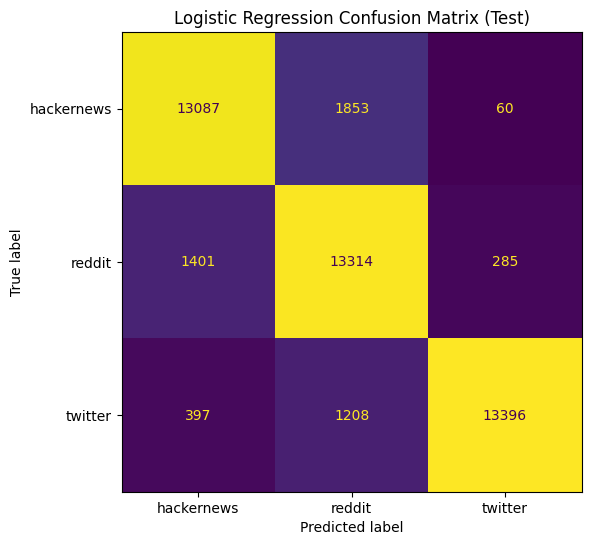

In [12]:
labels = sorted(y_test.unique())

cm = confusion_matrix(y_test, test_pred, labels=labels)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

fig, ax = plt.subplots(figsize=(6, 6))
disp.plot(ax=ax, colorbar=False)
plt.title("Logistic Regression Confusion Matrix (Test)")
plt.tight_layout()
plt.savefig(MODEL_OUTPUT_DIR / "logreg_confusion_matrix.png", dpi=150)
plt.show()

## Compare TF-IDF only vs TF-IDF + text statistics

In [13]:
tfidf_only_model = LogisticRegression(
    max_iter=5000,
    solver="saga",
    random_state=42,
)

tfidf_only_model.fit(X_train_tfidf, y_train)
val_pred_tfidf_only = tfidf_only_model.predict(X_val_tfidf)

comparison_df = pd.DataFrame({
    "model": ["TF-IDF only", "TF-IDF and text stats"],
    "validation_accuracy": [
        accuracy_score(y_val, val_pred_tfidf_only),
        val_accuracy,
    ],
})

comparison_df

,model,validation_accuracy
0,TF-IDF only,0.834156
1,TF-IDF and text stats,0.883467


## Look at the most informative features for each class

In [14]:
tfidf_vocab = tfidf.get_feature_names_out()
numeric_names = np.array(TEXT_STAT_COLS)
all_feature_names = np.concatenate([tfidf_vocab, numeric_names])

coef_df = pd.DataFrame(
    baseline_model.coef_.T,
    index=all_feature_names,
    columns=baseline_model.classes_,
)

In [15]:
top_n = 15
for cls in baseline_model.classes_:
    print(f"\n===== Top positive features for {cls} =====")
    print(coef_df[cls].sort_values(ascending=False).head(top_n))


===== Top positive features for hackernews =====
href              6.170306
rel               5.726285
nofollow          5.720946
rel nofollow      5.717845
href https        5.037784
nofollow https    4.302505
article           3.171806
hn                3.109340
probably          2.903705
point             2.884205
people            2.735991
com               2.730709
doesn             2.571255
yeah              2.508986
org               2.489845
Name: hackernews, dtype: float64

===== Top positive features for reddit =====
com            3.246050
telegram       3.201312
looking        2.801584
help           2.714401
overview       2.507207
guys           2.307590
https youtu    2.282965
youtu          2.266822
girl           2.213805
dm             2.078820
wondering      2.063476
reddit         2.054200
sub            2.034850
wanna          1.986714
cum            1.964674
Name: reddit, dtype: float64

===== Top positive features for twitter =====
https           17.150408
http

In [16]:
# Export logistic regression metrics for the dashboard
import json

LOGREG_OUTPUT_DIR = MODEL_OUTPUT_DIR / "logistic_regression"
LOGREG_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

logreg_metrics = {
    "model": "Logistic Regression (TF-IDF + text stats)",
    "validation_accuracy": float(val_accuracy),
    "test_accuracy": float(test_accuracy),
    "macro_f1": float(classification_report(y_test, test_pred, output_dict=True)["macro avg"]["f1-score"]),
    "weighted_f1": float(classification_report(y_test, test_pred, output_dict=True)["weighted avg"]["f1-score"]),
    "classes": [str(label) for label in labels],
    "classification_report": classification_report(y_test, test_pred, output_dict=True),
}

metrics_path = LOGREG_OUTPUT_DIR / "logreg_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(logreg_metrics, f, indent=2)

print(f"Saved metrics to: {metrics_path}")

Saved metrics to: /Users/mhedlund/CIS2450/cis2450-final-project/outputs/modeling/logistic_regression/logreg_metrics.json
